<a href="https://colab.research.google.com/github/MadhurAroraaa/Olist-Data-Analytics/blob/main/AroraXSinghal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olist E-Commerce: Turning Delivery Reliability Into Customer Experience

## Executive Summary

Our analysis of the Olist Brazilian e-commerce dataset identifies **delivery reliability as the strongest observable signal of customer dissatisfaction**.

Late-delivered orders had an average review score of **2.26★**, compared with **4.28★ for early deliveries**. Moreover, **62.8% of late orders received 1–2★ reviews**, versus only **9.5% of early deliveries**.

The effect becomes increasingly severe as delays grow: the 1–2★ review rate rises from **32.5% for orders 1–3 days late to 68.0% for orders 4–7 days late**.

The problem was not limited to isolated seller failures. A major deterioration in marketplace delivery reliability occurred around late 2017–early 2018. The late-delivery rate increased from **3.83% in Aug–Oct 2017 to 16.63% in Feb–Mar 2018**, while average review scores declined from **4.246★ to 3.830★**.

The evidence also shows that intervention should be targeted rather than uniform. High-priority state × category segments combine delivery risk with substantial low-rating burden. The clearest example is **RJ × Bed/Bath/Table**, with **15.1% late deliveries and 147 late orders receiving 1–2★ reviews**.

### Recommended operating model

1. **Prevent:** identify orders approaching their estimated delivery date without confirmed delivery.
2. **Prioritize:** focus intervention on high-risk destination × category segments.
3. **Escalate:** investigate sellers with persistent delivery underperformance.

### Important interpretation

These findings are based on observational data. They identify strong associations and intervention priorities but **do not establish that delivery lateness is the sole causal source of poor reviews**.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Configure display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Core libraries for Olist analysis loaded successfully.")

Core libraries for Olist analysis loaded successfully.


In [ ]:
# Load Olist Marketplace Datasets
customers = pd.read_csv("Document from singhlink4 - customers.csv")
geolocation = pd.read_csv("Document from singhlink4 - geolocation.csv")
order_items = pd.read_csv("Document from singhlink4 - order_items.csv")
order_payments = pd.read_csv("Document from singhlink4 - order_payments.csv")
order_reviews = pd.read_csv("Document from singhlink4 - order_reviews.csv")
orders = pd.read_csv("Document from singhlink4 - orders.csv")
products = pd.read_csv("Document from singhlink4 - products.csv")
sellers = pd.read_csv("Document from singhlink4 - sellers.csv")
category_translation = pd.read_csv("Document from singhlink4 - category_translation.csv")

# Consolidated Data Audit: Establish shapes and confirm load integrity
datasets = {
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "customers": customers,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": category_translation
}

print("Dataset Grain and Dimension Audit:")
print("-" * 50)
for name, df in datasets.items():
    print(f"{name:25} | Rows: {df.shape[0]:>7} | Columns: {df.shape[1]}")

Dataset Grain and Dimension Audit:
--------------------------------------------------
orders                    | Rows:   99441 | Columns: 8
order_items               | Rows:  112650 | Columns: 6
order_payments            | Rows:  103886 | Columns: 5
order_reviews             | Rows:  100000 | Columns: 7
customers                 | Rows:   99441 | Columns: 5
products                  | Rows:   32951 | Columns: 9
sellers                   | Rows:    3095 | Columns: 4
geolocation               | Rows: 1000163 | Columns: 5
category_translation      | Rows:      71 | Columns: 2


### Dataset Shape Verification
Summary of raw data records across all Olist tables.

In [ ]:
# 1. Date Processing & Metric Calculation
# Convert strings to datetime and filter for delivered population
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

delivered_orders = orders[orders["order_delivered_customer_date"].notna()].copy()

# 2. Performance Metrics (Calendar-Day Logic)
# We normalize to dates to ensure performance is measured in whole days
delivered_orders["actual_delivery_date"] = delivered_orders["order_delivered_customer_date"].dt.normalize()
delivered_orders["estimated_delivery_date_norm"] = delivered_orders["order_estimated_delivery_date"].dt.normalize()

delivered_orders["delivery_delay_days"] = (
    delivered_orders["actual_delivery_date"] - delivered_orders["estimated_delivery_date_norm"]
).dt.days

# 3. Delivery Status Classification
delivered_orders["delivery_status"] = "On-time"
delivered_orders.loc[delivered_orders["delivery_delay_days"] < 0, "delivery_status"] = "Early"
delivered_orders.loc[delivered_orders["delivery_delay_days"] > 0, "delivery_status"] = "Late"

# 4. Delivery Time Metric (Total duration)
delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"] - delivered_orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

print(f"Processing complete. Total delivered orders: {len(delivered_orders):,}")

Processing complete. Total delivered orders: 96,476


### Delivery Performance Distribution
Baseline classification of orders into Early, On-time, and Late categories.

In [ ]:
### 1. Review Processing & Aggregation
# Data Audit: Establish review grain and handle multiple reviews per order
print("--- Review Data Quality Audit ---")
print(f"Total review records: {len(order_reviews):,}")
print(f"Unique orders in reviews: {order_reviews['order_id'].nunique():,}")
print(f"Duplicated review_ids: {order_reviews['review_id'].duplicated().sum():,}")

review_counts = order_reviews.groupby('order_id').size()
print(f"Orders with multiple review records: {(review_counts > 1).sum():,}")

# Aggregation: Create one review score per order using the mean score
review_order_level = (
    order_reviews
    .groupby('order_id', as_index=False)
    .agg(review_score=('review_score', 'mean'))
)

# Join: Merge with the validated delivered_orders population
delivery_review_df = delivered_orders.merge(
    review_order_level,
    on='order_id',
    how='left',
    validate='one_to_one'
)

# Satisfaction Flags
delivery_review_df['low_review'] = (delivery_review_df['review_score'] <= 2)
delivery_review_df['high_review'] = (delivery_review_df['review_score'] >= 4)

print(f"\nMerge complete. Analysis population: {len(delivery_review_df):,} delivered orders.")

--- Review Data Quality Audit ---
Total review records: 100,000
Unique orders in reviews: 99,441
Duplicated review_ids: 827
Orders with multiple review records: 555

Merge complete. Analysis population: 96,476 delivered orders.


### Satisfaction Analysis by Delivery Delay
Quantifying the relationship between delivery status and review scores.

In [ ]:
### 3. Statistical Validation
# We use Mann-Whitney U for ordinal, non-normal review scores
early_scores = delivery_review_df[delivery_review_df['delivery_status'] == 'Early']['review_score']
late_scores = delivery_review_df[delivery_review_df['delivery_status'] == 'Late']['review_score']

stat, p_value = stats.mannwhitneyu(early_scores, late_scores, alternative='two-sided')

# Effect size: rank-biserial correlation
n1, n2 = len(early_scores), len(late_scores)
rank_biserial = 1 - (2 * stat) / (n1 * n2)

print("--- Statistical Significance: Early vs Late ---")
print(f"Mann-Whitney U statistic: {stat:,.1f}")
print(f"p-value: {p_value:.4e}")
print(f"Rank-biserial correlation: {rank_biserial:.4f}")

--- Statistical Significance: Early vs Late ---
Mann-Whitney U statistic: 475,003,963.5
p-value: 0.0000e+00
Rank-biserial correlation: -0.6399


In [ ]:
### Downstream Dependency & Data Integrity Check
# 1. Check for required objects in the namespace
required_objects = ['review_order_level', 'delivery_review_df']
missing_objects = [obj for obj in required_objects if obj not in globals()]

# 2. Check for required columns in delivery_review_df
required_columns = [
    'order_id', 'customer_id', 'order_purchase_timestamp',
    'delivery_delay_days', 'delivery_status',
    'review_score', 'low_review', 'high_review'
]

column_check = {}
if 'delivery_review_df' in globals():
    column_check = {col: (col in delivery_review_df.columns) for col in required_columns}

# 3. Report Results
print("--- Namespace Check ---")
print(f"Missing Objects: {missing_objects if missing_objects else 'None'}")

print("\n--- delivery_review_df Column Integrity ---")
for col, exists in column_check.items():
    status = "OK" if exists else "MISSING"
    dtype = delivery_review_df[col].dtype if exists else "N/A"
    print(f"{col:25}: {status} ({dtype})")

# 4. Logic Validation (Recalculating key metrics to ensure consistency)
if 'delivery_review_df' in globals():
    early_stats = delivery_review_df[delivery_review_df['delivery_status'] == 'Early'].agg({'review_score': 'mean', 'low_review': 'mean'})
    late_stats = delivery_review_df[delivery_review_df['delivery_status'] == 'Late'].agg({'review_score': 'mean', 'low_review': 'mean'})

    print("\n--- Metric Validation (Target vs. Actual) ---")
    print(f"Early Mean Review: {early_stats['review_score']:.2f} (Target: 4.28)")
    print(f"Late Mean Review:  {late_stats['review_score']:.2f} (Target: 2.26)")
    print(f"Late Low-Rating %: {late_stats['low_review']*100:.1f}% (Target: 62.8%)")

--- Namespace Check ---
Missing Objects: None

--- delivery_review_df Column Integrity ---
order_id                 : OK (object)
customer_id              : OK (object)
order_purchase_timestamp : OK (datetime64[ns])
delivery_delay_days      : OK (int64)
delivery_status          : OK (object)
review_score             : OK (float64)
low_review               : OK (bool)
high_review              : OK (bool)

--- Metric Validation (Target vs. Actual) ---
Early Mean Review: 4.28 (Target: 4.28)
Late Mean Review:  2.26 (Target: 2.26)
Late Low-Rating %: 62.8% (Target: 62.8%)


<!-- Removed redundant integrity check cell. The comprehensive diagnostic block at cell 64f445a8 is retained above. -->

In [ ]:
### 1. Category Translation & Mapping Logic
# Requirement: Establish one-row-per-order category mapping (English)
# Limitation: Excludes orders with missing or multiple categories to maintain grain integrity.

# A. Translate Products
products_translated = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

# B. Map Orders to Categories (Stricly 1-to-1)
item_categories = order_items.merge(
    products_translated[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)

categories_per_order = item_categories.groupby('order_id')['product_category_name_english'].nunique()
single_category_order_ids = categories_per_order[categories_per_order == 1].index

order_category = (
    item_categories[item_categories['order_id'].isin(single_category_order_ids)]
    .groupby('order_id', as_index=False)['product_category_name_english']
    .first()
)

# C. Create Primary Category Dataset
delivery_category_df = delivery_review_df.merge(
    order_category,
    on='order_id',
    how='inner',
    validate='one_to_one'
)

print(f"Category Mapping Complete.")
print(f"Rows in delivery_category_df: {len(delivery_category_df):,}")
print(f"Orders excluded (missing/multi-cat): {len(delivery_review_df) - len(delivery_category_df):,}")

Category Mapping Complete.
Rows in delivery_category_df: 94,402
Orders excluded (missing/multi-cat): 2,074


### Category-Level Satisfaction Impact
Identifying product categories most sensitive to delivery delays.

### Geographic Performance Summary
State-level delivery reliability and average customer satisfaction.

In [ ]:
import pandas as pd
import numpy as np

# Overall metrics
category_state_base = delivery_category_geo.groupby(
    ['customer_state', 'product_category_name_english'], observed=True
).agg(
    total_orders=('order_id', 'count'),
    late_orders=('delivery_status', lambda x: (x == 'Late').sum()),
    low_review_rate=('low_review', 'mean')
).reset_index()

category_state_base['late_rate'] = (category_state_base['late_orders'] / category_state_base['total_orders']) * 100
category_state_base['low_review_rate'] *= 100

# Late-only metrics
late_metrics = delivery_category_geo[delivery_category_geo['delivery_status'] == 'Late'].groupby(
    ['customer_state', 'product_category_name_english'], observed=True
).agg(
    avg_late_delay_days=('delivery_delay_days', 'mean'),
    late_low_review_rate=('low_review', 'mean')
).reset_index()

late_metrics['late_low_review_rate'] *= 100

# Merge and Filter
priority_combinations = category_state_base.merge(
    late_metrics,
    on=['customer_state', 'product_category_name_english'],
    how='left'
)

# Calculate burden for sorting/verification purposes
priority_combinations['late_low_review_orders'] = (
    priority_combinations['late_orders'] * priority_combinations['late_low_review_rate'] / 100
).fillna(0)

# Apply volume filter
priority_combinations = priority_combinations[priority_combinations['total_orders'] >= 200].copy()

# Sort and Display
priority_combinations = priority_combinations.sort_values('late_low_review_orders', ascending=False)

# Verification Output
print("FIXED")
print(f"Columns now present: {priority_combinations.columns.tolist()}")

top_5 = priority_combinations.head(5)
print("\n--- Top 5 Verification ---")
display(top_5[[
    'customer_state',
    'product_category_name_english',
    'total_orders',
    'late_orders',
    'late_rate',
    'avg_late_delay_days',
    'late_low_review_rate'
]])

# Check downstream compatibility (ensuring expected variables exist)
proceed_safe = 'late_low_review_rate' in priority_combinations.columns
print(f"\nDownstream compatibility: {'PASS' if proceed_safe else 'FAIL'}")

FIXED
Columns now present: ['customer_state', 'product_category_name_english', 'total_orders', 'late_orders', 'low_review_rate', 'late_rate', 'avg_late_delay_days', 'late_low_review_rate', 'late_low_review_orders']

--- Top 5 Verification ---


,customer_state,product_category_name_english,total_orders,late_orders,late_rate,avg_late_delay_days,late_low_review_rate
905,RJ,bed_bath_table,1333,201,15.078770,13.278607,73.134328
1281,SP,health_beauty,3678,200,5.437738,7.085000,51.500000
1245,SP,bed_bath_table,4260,176,4.131455,9.659091,57.954545
961,RJ,sports_leisure,882,124,14.058957,13.346774,72.580645
913,RJ,computers_accessories,824,103,12.500000,12.941748,78.640777



Downstream compatibility: PASS


In [ ]:
delivery_category_seller = delivery_category_geo.merge(
    order_items[["order_id", "seller_id"]].drop_duplicates("order_id"),
    on="order_id",
    how="left",
    validate="one_to_one"
)

delivery_category_seller = delivery_category_seller.merge(
    sellers[["seller_id", "seller_state"]],
    on="seller_id",
    how="left",
    validate="many_to_one"
)

print("Rows:", len(delivery_category_seller))
print("Unique orders:", delivery_category_seller["order_id"].nunique())
print("Missing seller ID:", delivery_category_seller["seller_id"].isna().sum())
print("Missing seller state:", delivery_category_seller["seller_state"].isna().sum())

Rows: 94402
Unique orders: 94402
Missing seller ID: 0
Missing seller state: 0


In [ ]:
delivery_category_seller["route_type"] = np.where(
    delivery_category_seller["seller_state"]
    == delivery_category_seller["customer_state"],
    "Same-state",
    "Cross-state"
)

route_analysis = (
    delivery_category_seller
    .groupby("route_type")
    .agg(
        orders=("order_id", "count"),
        late_orders=("delivery_status", lambda x: (x == "Late").sum()),
        avg_review_score=("review_score", "mean"),
        low_review_rate=("low_review", "mean")
    )
    .reset_index()
)

route_analysis["late_rate"] = (
    route_analysis["late_orders"]
    / route_analysis["orders"]
    * 100
)

route_analysis["low_review_rate"] *= 100

display(route_analysis)

,route_type,orders,late_orders,avg_review_score,low_review_rate,late_rate
0,Cross-state,60454,4897,4.091273,14.181030,8.100374
1,Same-state,33948,1531,4.261071,10.489572,4.509839


In [ ]:
### 1. Geolocation Aggregation & Coordinate Mapping
# Requirement: Aggregate to ZIP-prefix level and map coordinates to customers/sellers.

# A. Aggregate Geolocation
geo_prefix = (
    geolocation
    .groupby('geolocation_zip_code_prefix', as_index=False)
    .agg(
        latitude=('geolocation_lat', 'mean'),
        longitude=('geolocation_lng', 'mean')
    )
)

# B. Map Coordinates
customers_geo = customers.merge(
    geo_prefix,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

sellers_geo = sellers.merge(
    geo_prefix,
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

print(f"Geolocation aggregation complete.")
print(f"Unique ZIP prefixes: {len(geo_prefix):,}")
print(f"Customers missing coords: {customers_geo['latitude'].isna().sum()}")

Geolocation aggregation complete.
Unique ZIP prefixes: 19,015
Customers missing coords: 278


In [ ]:
### 2. Distance Calculation (Haversine Logic)
# Requirement: Create distance_df and calculate straight-line distance.

# A. Primary Join to Create distance_df
distance_df = delivery_category_seller.merge(
    customers_geo[['customer_id', 'latitude', 'longitude']],
    on='customer_id',
    how='left'
).rename(columns={'latitude': 'customer_latitude', 'longitude': 'customer_longitude'})

distance_df = distance_df.merge(
    sellers_geo[['seller_id', 'latitude', 'longitude']].rename(
        columns={'latitude': 'seller_latitude', 'longitude': 'seller_longitude'}
    ),
    on='seller_id',
    how='left'
)

# B. Haversine Formula
lat1, lon1 = np.radians(distance_df['seller_latitude']), np.radians(distance_df['seller_longitude'])
lat2, lon2 = np.radians(distance_df['customer_latitude']), np.radians(distance_df['customer_longitude'])

dlat, dlon = lat2 - lat1, lon2 - lon1
a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
c = 2 * np.arcsin(np.sqrt(a))

distance_df['estimated_distance_km'] = 6371 * c

print(f"Distance calculation complete.")
print(f"Rows in distance_df: {len(distance_df):,}")
print(f"Orders with distance: {distance_df['estimated_distance_km'].notna().sum():,}")

Distance calculation complete.
Rows in distance_df: 94,402
Orders with distance: 93,932


In [ ]:
### 3. Logistics Performance Analysis
# Requirement: Establish distance_analysis and performance buckets.

distance_analysis = distance_df[distance_df['estimated_distance_km'].notna()].copy()

distance_analysis['distance_bucket'] = pd.cut(
    distance_analysis['estimated_distance_km'],
    bins=[0, 100, 250, 500, 750, 1000, np.inf],
    labels=['<100 km', '100–250 km', '250–500 km', '500–750 km', '750–1000 km', '1000+ km'],
    include_lowest=True
)

distance_performance = (
    distance_analysis
    .groupby(['distance_bucket', 'delivery_status'], observed=True)
    .agg(
        orders=('order_id', 'count'),
        avg_review_score=('review_score', 'mean'),
        low_review_rate=('low_review', 'mean')
    )
    .reset_index()
)

distance_performance['low_review_rate'] *= 100

# Integrity Check for Downstream
proceed_safe = 'estimated_distance_km' in distance_analysis.columns and 'distance_bucket' in distance_analysis.columns
print(f"Logistics analysis complete.")
print(f"Rows in distance_analysis: {len(distance_analysis):,}")
print(f"Downstream compatibility check: {'PASS' if proceed_safe else 'FAIL'}")
display(distance_performance.head())

Logistics analysis complete.
Rows in distance_analysis: 93,932
Downstream compatibility check: PASS


,distance_bucket,delivery_status,orders,avg_review_score,low_review_rate
0,<100 km,Early,16354,4.346725,8.530023
1,<100 km,Late,780,2.755128,49.487179
2,<100 km,On-time,339,4.103245,13.569322
3,100–250 km,Early,8608,4.377498,7.632435
4,100–250 km,Late,450,2.488889,55.777778


In [ ]:
### Monthly Marketplace Metrics Consolidation

In [ ]:
### Logistic Regression Analysis: Impact of Logistics on Satisfaction

In [ ]:
### Business Impact & Intervention Priority Analysis

In [ ]:
### Payment Method & Freight Burden Analysis

In [ ]:
# Create monthly marketplace metrics

orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_performance = (
    orders
    .groupby("purchase_month")
    .agg(
        orders=("order_id", "count")
    )
    .reset_index()
)

monthly_performance.head()

,purchase_month,orders
0,2016-09-01,4
1,2016-10-01,324
2,2016-12-01,1
3,2017-01-01,800
4,2017-02-01,1780


In [ ]:
# Calculate monthly order value from item prices
# IMPORTANT: aggregate items to order level first.

order_values = (
    order_items
    .groupby("order_id")
    .agg(
        item_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
    .reset_index()
)

order_values["order_value"] = (
    order_values["item_value"]
    + order_values["freight_value"]
)

monthly_performance = (
    orders[
        ["order_id", "purchase_month"]
    ]
    .merge(
        order_values[["order_id", "order_value"]],
        on="order_id",
        how="left",
        validate="one_to_one"
    )
    .groupby("purchase_month")
    .agg(
        orders=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        avg_order_value=("order_value", "mean")
    )
    .reset_index()
)

monthly_performance.head()

,purchase_month,orders,total_order_value,avg_order_value
0,2016-09-01,4,354.75,118.250000
1,2016-10-01,324,56808.84,184.444286
2,2016-12-01,1,19.62,19.620000
3,2017-01-01,800,137188.49,173.876413
4,2017-02-01,1780,286280.62,165.193664


In [ ]:
# Add purchase month to the order-level delivery/review data

delivery_review_df["purchase_month"] = (
    delivery_review_df["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_reviews = (
    delivery_review_df
    .groupby("purchase_month")
    .agg(
        avg_review_score=("review_score", "mean"),
        low_review_rate=("low_review", "mean"),
        delivered_orders=("order_id", "count")
    )
    .reset_index()
)

monthly_reviews["low_review_rate"] *= 100

monthly_reviews.head()

,purchase_month,avg_review_score,low_review_rate,delivered_orders
0,2016-09-01,1.000000,100.000000,1
1,2016-10-01,3.935185,18.518519,270
2,2016-12-01,5.000000,0.000000,1
3,2017-01-01,4.184667,12.400000,750
4,2017-02-01,4.189958,11.373261,1653


In [ ]:
# Combine marketplace performance + customer satisfaction

monthly_performance = monthly_performance.merge(
    monthly_reviews[
        [
            "purchase_month",
            "avg_review_score",
            "low_review_rate"
        ]
    ],
    on="purchase_month",
    how="left",
    validate="one_to_one"
)

monthly_performance

,purchase_month,orders,total_order_value,avg_order_value,avg_review_score,low_review_rate
0,2016-09-01,4,354.75,118.250000,1.000000,100.000000
1,2016-10-01,324,56808.84,184.444286,3.935185,18.518519
2,2016-12-01,1,19.62,19.620000,5.000000,0.000000
3,2017-01-01,800,137188.49,173.876413,4.184667,12.400000
4,2017-02-01,1780,286280.62,165.193664,4.189958,11.373261
5,2017-03-01,2682,432048.59,163.592802,4.171445,11.586803
6,2017-04-01,2404,412422.24,172.489435,4.128962,13.026487
7,2017-05-01,3700,586190.95,160.161462,4.223131,10.437236
8,2017-06-01,3245,502963.04,156.345365,4.206539,11.036683
9,2017-07-01,4026,584971.62,147.385140,4.246600,10.201446


In [ ]:
# Calculate monthly delivery performance
# Only delivered orders are included because non-delivered orders
# do not have a meaningful delivery-delay measurement.

monthly_delivery = (
    delivered_orders
    .assign(
        purchase_month=(
            delivered_orders["order_purchase_timestamp"]
            .dt.to_period("M")
            .dt.to_timestamp()
        )
    )
    .groupby("purchase_month")
    .agg(
        delivered_orders=("order_id", "count"),
        late_orders=(
            "delivery_status",
            lambda x: (x == "Late").sum()
        )
    )
    .reset_index()
)

monthly_delivery["late_rate"] = (
    monthly_delivery["late_orders"]
    / monthly_delivery["delivered_orders"]
    * 100
)

monthly_delivery

,purchase_month,delivered_orders,late_orders,late_rate
0,2016-09-01,1,1,100.000000
1,2016-10-01,270,2,0.740741
2,2016-12-01,1,0,0.000000
3,2017-01-01,750,22,2.933333
4,2017-02-01,1653,49,2.964307
5,2017-03-01,2546,116,4.556167
6,2017-04-01,2303,151,6.556665
7,2017-05-01,3545,106,2.990127
8,2017-06-01,3135,95,3.030303
9,2017-07-01,3872,108,2.789256


In [ ]:
# Add delivery performance to the monthly marketplace table

monthly_performance = monthly_performance.merge(
    monthly_delivery[
        [
            "purchase_month",
            "delivered_orders",
            "late_orders",
            "late_rate"
        ]
    ],
    on="purchase_month",
    how="left",
    validate="one_to_one"
)

monthly_performance

,purchase_month,orders,total_order_value,avg_order_value,avg_review_score,low_review_rate,delivered_orders,late_orders,late_rate
0,2016-09-01,4,354.75,118.250000,1.000000,100.000000,1.0,1.0,100.000000
1,2016-10-01,324,56808.84,184.444286,3.935185,18.518519,270.0,2.0,0.740741
2,2016-12-01,1,19.62,19.620000,5.000000,0.000000,1.0,0.0,0.000000
3,2017-01-01,800,137188.49,173.876413,4.184667,12.400000,750.0,22.0,2.933333
4,2017-02-01,1780,286280.62,165.193664,4.189958,11.373261,1653.0,49.0,2.964307
5,2017-03-01,2682,432048.59,163.592802,4.171445,11.586803,2546.0,116.0,4.556167
6,2017-04-01,2404,412422.24,172.489435,4.128962,13.026487,2303.0,151.0,6.556665
7,2017-05-01,3700,586190.95,160.161462,4.223131,10.437236,3545.0,106.0,2.990127
8,2017-06-01,3245,502963.04,156.345365,4.206539,11.036683,3135.0,95.0,3.030303
9,2017-07-01,4026,584971.62,147.385140,4.246600,10.201446,3872.0,108.0,2.789256


In [ ]:
# Calculate severity of late deliveries by purchase month

monthly_late_severity = (
    delivered_orders[
        delivered_orders["delivery_status"] == "Late"
    ]
    .assign(
        purchase_month=(
            delivered_orders.loc[
                delivered_orders["delivery_status"] == "Late",
                "order_purchase_timestamp"
            ]
            .dt.to_period("M")
            .dt.to_timestamp()
        )
    )
    .groupby("purchase_month")
    .agg(
        late_orders=("order_id", "count"),
        avg_late_delay_days=("delivery_delay_days", "mean")
    )
    .reset_index()
)

monthly_late_severity

,purchase_month,late_orders,avg_late_delay_days
0,2016-09-01,1,36.000000
1,2016-10-01,2,9.500000
2,2017-01-01,22,20.227273
3,2017-02-01,49,20.795918
4,2017-03-01,116,25.431034
5,2017-04-01,151,12.337748
6,2017-05-01,106,12.537736
7,2017-06-01,95,14.263158
8,2017-07-01,108,11.685185
9,2017-08-01,122,8.786885


In [ ]:
# Add late-delivery severity to the monthly performance table

monthly_performance = monthly_performance.merge(
    monthly_late_severity,
    on="purchase_month",
    how="left",
    validate="one_to_one"
)

monthly_performance[
    [
        "purchase_month",
        "orders",
        "late_rate",
        "avg_late_delay_days",
        "avg_review_score",
        "low_review_rate"
    ]
]

,purchase_month,orders,late_rate,avg_late_delay_days,avg_review_score,low_review_rate
0,2016-09-01,4,100.000000,36.000000,1.000000,100.000000
1,2016-10-01,324,0.740741,9.500000,3.935185,18.518519
2,2016-12-01,1,0.000000,NaN,5.000000,0.000000
3,2017-01-01,800,2.933333,20.227273,4.184667,12.400000
4,2017-02-01,1780,2.964307,20.795918,4.189958,11.373261
5,2017-03-01,2682,4.556167,25.431034,4.171445,11.586803
6,2017-04-01,2404,6.556665,12.337748,4.128962,13.026487
7,2017-05-01,3700,2.990127,12.537736,4.223131,10.437236
8,2017-06-01,3245,3.030303,14.263158,4.206539,11.036683
9,2017-07-01,4026,2.789256,11.685185,4.246600,10.201446


In [ ]:
# Compare customer-state late rates during the March 2018 spike
# against the rest of the period.

delivery_category_geo["purchase_month"] = (
    delivery_category_geo["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

march_2018 = delivery_category_geo[
    delivery_category_geo["purchase_month"] == "2018-03-01"
].copy()

print("March 2018 orders:", len(march_2018))

march_state = (
    march_2018
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "count"),
        late_orders=(
            "delivery_status",
            lambda x: (x == "Late").sum()
        )
    )
    .reset_index()
)

march_state["late_rate"] = (
    march_state["late_orders"]
    / march_state["total_orders"]
    * 100
)

march_state = march_state[
    march_state["total_orders"] >= 100
].sort_values(
    "late_rate",
    ascending=False
)

march_state

March 2018 orders: 6834


,customer_state,total_orders,late_orders,late_rate
7,ES,129,53,41.085271
18,RJ,848,293,34.551887
4,BA,227,71,31.277533
10,MG,829,173,20.868516
15,PE,106,22,20.754717
8,GO,133,27,20.300752
22,RS,389,78,20.051414
23,SC,238,46,19.327731
6,DF,146,27,18.493151
17,PR,360,49,13.611111


In [ ]:
# Check whether the March 2018 late-delivery spike was widespread across categories

march_category = (
    march_2018
    .groupby("product_category_name_english", observed=True)
    .agg(
        total_orders=("order_id", "count"),
        late_orders=(
            "delivery_status",
            lambda x: (x == "Late").sum()
        ),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
)

march_category["late_rate"] = (
    march_category["late_orders"]
    / march_category["total_orders"]
    * 100
)

# Keep categories with at least 100 March orders
march_category = march_category[
    march_category["total_orders"] >= 100
].sort_values(
    "late_rate",
    ascending=False
)

march_category

,product_category_name_english,total_orders,late_orders,avg_review_score,late_rate
64,watches_gifts,404,100,3.727723,24.752475
38,health_beauty,604,144,3.763245,23.841060
25,fashion_bags_accessories,127,29,3.877953,22.834646
6,bed_bath_table,642,139,3.663551,21.651090
54,perfumery,179,37,4.000000,20.670391
62,telephony,316,65,3.601266,20.569620
59,sports_leisure,641,127,3.828393,19.812793
37,garden_tools,192,38,3.893229,19.791667
55,pet_shop,107,21,3.785047,19.626168
60,stationery,143,28,3.860140,19.580420


In [ ]:
# Add purchase month to the seller analysis dataset

delivery_category_seller["purchase_month"] = (
    delivery_category_seller["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

print(
    delivery_category_seller[
        "purchase_month"
    ].min()
)

print(
    delivery_category_seller[
        "purchase_month"
    ].max()
)

2016-09-01 00:00:00
2018-08-01 00:00:00


In [ ]:
# Define pre-crisis and crisis periods

pre_crisis = delivery_review_df[
    delivery_review_df["purchase_month"].isin(
        pd.to_datetime(["2017-08-01", "2017-09-01", "2017-10-01"])
    )
]["review_score"]

crisis = delivery_review_df[
    delivery_review_df["purchase_month"].isin(
        pd.to_datetime(["2018-02-01", "2018-03-01"])
    )
]["review_score"]

print("Pre-crisis orders:", len(pre_crisis))
print("Crisis orders:", len(crisis))

print("\nPre-crisis average rating:", pre_crisis.mean())
print("Crisis average rating:", crisis.mean())

Pre-crisis orders: 12821
Crisis orders: 13559

Pre-crisis average rating: 4.246002651899228
Crisis average rating: 3.8298792929665413


In [ ]:
# Compare the review-score distributions statistically

stat, p_value = stats.mannwhitneyu(
    pre_crisis,
    crisis,
    alternative="two-sided"
)

print("Mann-Whitney U:", stat)
print("p-value:", p_value)

Mann-Whitney U: 99090196.0
p-value: 2.9610474003253722e-105


In [ ]:
# Compare delivery reliability between the pre-crisis and crisis periods

pre_crisis_delivery = delivery_review_df[
    delivery_review_df["purchase_month"].isin(
        pd.to_datetime([
            "2017-08-01",
            "2017-09-01",
            "2017-10-01"
        ])
    )
]

crisis_delivery = delivery_review_df[
    delivery_review_df["purchase_month"].isin(
        pd.to_datetime([
            "2018-02-01",
            "2018-03-01"
        ])
    )
]

pre_late_rate = (
    pre_crisis_delivery["delivery_status"].eq("Late").mean() * 100
)

crisis_late_rate = (
    crisis_delivery["delivery_status"].eq("Late").mean() * 100
)

print("Pre-crisis late rate:", round(pre_late_rate, 2), "%")
print("Crisis late rate:", round(crisis_late_rate, 2), "%")

print(
    "Increase:",
    round(crisis_late_rate - pre_late_rate, 2),
    "percentage points"
)

Pre-crisis late rate: 3.83 %
Crisis late rate: 16.63 %
Increase: 12.8 percentage points


In [ ]:
# Calculate the relative increase in late-delivery exposure

relative_increase = (
    (crisis_late_rate - pre_late_rate)
    / pre_late_rate
    * 100
)

print(
    "Relative increase in late rate:",
    round(relative_increase, 2),
    "%"
)

Relative increase in late rate: 334.27 %


In [ ]:
# Add order value and freight value to the distance analysis

model_df = distance_analysis.merge(
    order_values[
        [
            "order_id",
            "order_value",
            "freight_value"
        ]
    ],
    on="order_id",
    how="left",
    validate="one_to_one"
)

print("Rows:", len(model_df))
print("Unique orders:", model_df["order_id"].nunique())
print(
    "Missing order values:",
    model_df["order_value"].isna().sum()
)

Rows: 93932
Unique orders: 93932
Missing order values: 0


In [ ]:
# Create the variables needed for modelling
model_df['cross_state'] = (model_df['customer_state'] != model_df['seller_state']).astype(int)

# Convert the target variable from True/False to 1/0
model_df['low_review_binary'] = model_df['low_review'].astype(int)

print(f"Variable engineering complete. Observations: {len(model_df):,}")
print(model_df['low_review_binary'].value_counts())

Variable engineering complete. Observations: 93,932
low_review_binary
0    81850
1    12082
Name: count, dtype: int64


In [ ]:
# Prepare variables for the first logistic regression

model_df["delivery_status_model"] = pd.Categorical(
    model_df["delivery_delay_days"].apply(
        lambda x:
            "Early" if x < 0
            else "On-time" if x == 0
            else "Late"
    ),
    categories=["Early", "On-time", "Late"]
)

# Log-transform highly skewed monetary/distance variables
# +1 prevents log(0) problems.

model_df["log_order_value"] = np.log1p(model_df["order_value"])
model_df["log_freight_value"] = np.log1p(model_df["freight_value"])
model_df["log_distance"] = np.log1p(model_df["estimated_distance_km"])

# Make categorical variables explicit
model_df["customer_state"] = model_df["customer_state"].astype("category")
model_df["product_category_name_english"] = (
    model_df["product_category_name_english"].astype("category")
)

print(
    model_df[
        [
            "low_review",
            "delivery_status_model",
            "log_order_value",
            "log_freight_value",
            "log_distance",
            "cross_state",
            "customer_state",
            "product_category_name_english"
        ]
    ].head()
)

   low_review delivery_status_model  log_order_value  log_freight_value  \
0       False                 Early         3.681603           2.274186   
1       False                 Early         4.959061           3.168003   
2       False                 Early         5.193623           3.006672   
3       False                 Early         4.293195           3.339322   
4       False                 Early         3.388450           2.274186   

   log_distance  cross_state customer_state product_category_name_english  
0      2.974310            0             SP                    housewares  
1      6.748167            1             BA                     perfumery  
2      6.244964            1             GO                          auto  
3      7.508363            1             RN                      pet_shop  
4      3.423501            0             SP                    stationery  


In [ ]:
### Seller Population & Operational Concentration

In [ ]:
### Data Visualizations & Executive Recommendations

In [ ]:
# Simpler logistic regression
# Goal: test whether delivery status remains important
# after controlling for basic geography/logistics variables.

simple_formula = """
low_review_binary ~ C(delivery_status_model)
                  + log_distance
                  + log_freight_value
                  + log_order_value
                  + cross_state
                  + C(customer_state)
"""

simple_logit = smf.logit(
    simple_formula,
    data=model_df
).fit(
    disp=False,
    maxiter=200
)

print(simple_logit.summary())

                           Logit Regression Results                           
Dep. Variable:      low_review_binary   No. Observations:                93932
Model:                          Logit   Df Residuals:                    93899
Method:                           MLE   Df Model:                           32
Date:                Sun, 06 Sep 2026   Pseudo R-squ.:                  0.1467
Time:                        11:20:56   Log-Likelihood:                -30758.
converged:                       True   LL-Null:                       -36048.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -3.7265      0.363    -10.264      0.000      -4.438      -3.015
C(delivery_status_model)[T.On-time]     0.3612      0.08

In [ ]:
# Extract delivery-status odds ratios safely

simple_or = pd.DataFrame({
    "variable": simple_logit.params.index,
    "odds_ratio": np.exp(simple_logit.params),
    "p_value": simple_logit.pvalues
})

simple_or[
    simple_or["variable"].str.contains(
        "delivery_status_model"
    )
]

,variable,odds_ratio,p_value
C(delivery_status_model)[T.On-time],C(delivery_status_model)[T.On-time],1.435044,0.000031
C(delivery_status_model)[T.Late],C(delivery_status_model)[T.Late],16.375955,0.000000


In [ ]:
### Robustness Check: 1-Star Review Modeling

In [ ]:
# Create a stricter dissatisfaction target: 1-star review only
model_df['one_star_review'] = (model_df['review_score'] == 1).astype(int)

# Logistic regression for 1-star reviews (Robustness Check)
one_star_formula = """
one_star_review ~ C(delivery_status_model)
                + log_distance
                + log_freight_value
                + log_order_value
                + cross_state
                + C(customer_state)
"""

one_star_logit = smf.logit(one_star_formula, data=model_df).fit(disp=False, maxiter=200)
print(one_star_logit.summary())

                           Logit Regression Results                           
Dep. Variable:        one_star_review   No. Observations:                93932
Model:                          Logit   Df Residuals:                    93899
Method:                           MLE   Df Model:                           32
Date:                Sun, 06 Sep 2026   Pseudo R-squ.:                  0.1608
Time:                        11:20:59   Log-Likelihood:                -25298.
converged:                       True   LL-Null:                       -30147.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -4.6982      0.472     -9.961      0.000      -5.623      -3.774
C(delivery_status_model)[T.On-time]     0.3197      0.10

In [ ]:
# Extract delivery-status odds ratios

one_star_or = pd.DataFrame({
    "variable": one_star_logit.params.index,
    "odds_ratio": np.exp(one_star_logit.params),
    "p_value": one_star_logit.pvalues
})

one_star_or[
    one_star_or["variable"].str.contains(
        "delivery_status_model"
    )
]

,variable,odds_ratio,p_value
C(delivery_status_model)[T.On-time],C(delivery_status_model)[T.On-time],1.376770,0.001666
C(delivery_status_model)[T.Late],C(delivery_status_model)[T.Late],16.393164,0.000000


In [ ]:
# Business impact of late delivery

late_orders = delivery_review_df[
    delivery_review_df["delivery_status"] == "Late"
]

early_orders = delivery_review_df[
    delivery_review_df["delivery_status"] == "Early"
]

print("Late orders:", len(late_orders))
print("Early orders:", len(early_orders))

print(
    "\n1-star rate among late orders:",
    round(
        (late_orders["review_score"] == 1).mean() * 100,
        2
    ),
    "%"
)

print(
    "1-star rate among early orders:",
    round(
        (early_orders["review_score"] == 1).mean() * 100,
        2
    ),
    "%"
)

print(
    "\n1–2 star rate among late orders:",
    round(
        (late_orders["review_score"] <= 2).mean() * 100,
        2
    ),
    "%"
)

print(
    "1–2 star rate among early orders:",
    round(
        (early_orders["review_score"] <= 2).mean() * 100,
        2
    ),
    "%"
)

Late orders: 6535
Early orders: 88649

1-star rate among late orders: 54.08 %
1-star rate among early orders: 6.78 %

1–2 star rate among late orders: 62.8 %
1–2 star rate among early orders: 9.46 %


In [ ]:
# Quantify the 1-star review burden among late orders

total_one_star = (
    delivery_review_df["review_score"] == 1
).sum()

late_one_star = (
    (delivery_review_df["delivery_status"] == "Late")
    & (delivery_review_df["review_score"] == 1)
).sum()

share_one_star_from_late = (
    late_one_star / total_one_star * 100
)

print("Total 1-star reviews:", total_one_star)
print("1-star reviews from late orders:", late_one_star)
print(
    "Share of 1-star reviews coming from late orders:",
    round(share_one_star_from_late, 2),
    "%"
)

Total 1-star reviews: 9662
1-star reviews from late orders: 3534
Share of 1-star reviews coming from late orders: 36.58 %


In [ ]:
# Create simple flags first

category_data = delivery_category_geo.copy()

category_data["one_star"] = (
    category_data["review_score"] == 1
).astype(int)

category_data["late_one_star"] = (
    (category_data["delivery_status"] == "Late") &
    (category_data["review_score"] == 1)
).astype(int)


# Aggregate by category

category_one_star = (
    category_data
    .groupby("product_category_name_english", observed=True)
    .agg(
        total_orders=("order_id", "count"),
        late_orders=(
            "delivery_status",
            lambda x: (x == "Late").sum()
        ),
        total_one_star=("one_star", "sum"),
        late_one_star=("late_one_star", "sum")
    )
    .reset_index()
)


# Calculate useful percentages

category_one_star["late_rate"] = (
    category_one_star["late_orders"]
    / category_one_star["total_orders"]
    * 100
)

category_one_star["share_of_one_stars_from_late"] = np.where(
    category_one_star["total_one_star"] > 0,
    category_one_star["late_one_star"]
    / category_one_star["total_one_star"]
    * 100,
    np.nan
)


# Keep categories with at least 500 orders

category_one_star = category_one_star[
    category_one_star["total_orders"] >= 500
].copy()


# Sort by number of late 1-star orders

category_one_star = category_one_star.sort_values(
    "late_one_star",
    ascending=False
)

category_one_star.head(20)

,product_category_name_english,total_orders,late_orders,total_one_star,late_one_star,late_rate,share_of_one_stars_from_late
7,bed_bath_table,9075,684,1088,379,7.537190,34.834559
43,health_beauty,8579,649,786,340,7.564984,43.256997
65,sports_leisure,7463,493,672,297,6.605923,44.196429
15,computers_accessories,6479,417,729,226,6.436178,31.001372
39,furniture_decor,6105,446,666,226,7.305487,33.933934
70,watches_gifts,5453,406,574,223,7.445443,38.850174
49,housewares,5641,307,482,167,5.442297,34.647303
5,auto,3774,278,369,154,7.366190,41.734417
69,toys,3754,241,342,144,6.419819,42.105263
68,telephony,4066,291,425,136,7.156911,32.000000


In [ ]:
### 1. Payment Aggregation & Grain Audit
# Requirement: Establish payment_order_level (99,440 orders)

print(f"Raw payment records: {len(order_payments):,}")

# Sort to identify primary payment (largest value per order)
order_payments_sorted = order_payments.sort_values(['order_id', 'payment_value'], ascending=[True, False])

payment_order_level = order_payments.groupby('order_id', as_index=False).agg(
    total_payment_value=('payment_value', 'sum'),
    payment_method_count=('payment_type', 'nunique'),
    max_installments=('payment_installments', 'max')
)

primary_payment = order_payments_sorted.drop_duplicates('order_id')[['order_id', 'payment_type']].rename(
    columns={'payment_type': 'primary_payment_type'}
)

payment_order_level = payment_order_level.merge(primary_payment, on='order_id', how='left', validate='one_to_one')

print(f"Consolidated payment_order_level: {len(payment_order_level):,} unique orders")
display(payment_order_level['primary_payment_type'].value_counts().to_frame())


Raw payment records: 103,886
Consolidated payment_order_level: 99,440 unique orders


,count
primary_payment_type,
credit_card,74975
boleto,19784
voucher,3151
debit_card,1527
not_defined,3


In [ ]:
### 2. Payment Method & Installment Analysis
# Requirement: Compare satisfaction across payment types

payment_analysis = delivery_review_df.merge(payment_order_level, on='order_id', how='left', validate='one_to_one')

payment_summary = payment_analysis.groupby('primary_payment_type', dropna=False).agg(
    orders=('order_id', 'count'),
    avg_payment_value=('total_payment_value', 'mean'),
    avg_installments=('max_installments', 'mean'),
    avg_review_score=('review_score', 'mean'),
    low_review_rate=('low_review', 'mean'),
    late_rate=('delivery_status', lambda x: (x == 'Late').mean())
).reset_index()

payment_summary['low_review_rate'] *= 100
payment_summary['late_rate'] *= 100

print(f"Payment Analysis Population: {len(payment_analysis):,}")
# Conclusion: Payment method differences (4.10–4.23★) are small compared to delivery status
display(payment_summary.sort_values('orders', ascending=False))


Payment Analysis Population: 96,476


,primary_payment_type,orders,avg_payment_value,avg_installments,avg_review_score,low_review_rate,late_rate
1,credit_card,72824,166.180518,3.548212,4.142293,13.179721,6.687356
0,boleto,19191,144.334979,1.000000,4.142358,12.901881,7.321140
3,voucher,2977,114.864599,1.145784,4.107267,13.940208,6.046355
2,debit_card,1483,140.267620,1.000000,4.231625,11.328388,5.327040
4,NaN,1,NaN,NaN,1.000000,100.000000,100.000000


In [ ]:
### 3. Freight Share & Burden Analysis
# Requirement: Establish freight_analysis and evaluate burden on satisfaction

freight_analysis = payment_analysis.merge(
    order_values[['order_id', 'order_value', 'freight_value']],
    on='order_id', how='left', validate='one_to_one'
)

freight_analysis['freight_share'] = np.where(
    freight_analysis['order_value'] > 0,
    freight_analysis['freight_value'] / freight_analysis['order_value'] * 100,
    np.nan
)

freight_analysis['freight_bucket'] = pd.cut(
    freight_analysis['freight_share'],
    bins=[-np.inf, 10, 20, 30, 40, 50, np.inf],
    labels=['<10%', '10–20%', '20–30%', '30–40%', '40–50%', '50%+']
)

freight_summary = freight_analysis.groupby('freight_bucket', observed=True).agg(
    orders=('order_id', 'count'),
    avg_review_score=('review_score', 'mean'),
    low_review_rate=('low_review', 'mean'),
    late_rate=('delivery_status', lambda x: (x == 'Late').mean())
).reset_index()

freight_summary['low_review_rate'] *= 100
freight_summary['late_rate'] *= 100

# Downstream Compatibility Check
check_vars = ['primary_payment_type', 'freight_share']
pass_fail = "PASS" if all(v in freight_analysis.columns for v in check_vars) else "FAIL"

print(f"Freight Analysis rows: {len(freight_analysis):,}")
print(f"Downstream compatibility: {pass_fail}")
display(freight_summary)


Freight Analysis rows: 96,476
Downstream compatibility: PASS


,freight_bucket,orders,avg_review_score,low_review_rate,late_rate
0,<10%,18143,4.193463,12.660530,6.917268
1,10–20%,35281,4.152046,12.774581,6.544599
2,20–30%,23217,4.125770,13.459965,6.779515
3,30–40%,11611,4.114403,13.452760,6.700543
4,40–50%,5149,4.110118,13.361818,7.030491
5,50%+,3075,4.020976,15.577236,8.357724


In [ ]:
### 1. Seller Population & Attribution Logic
# Requirement: Establish seller_analysis_df using single-seller attribution
# Finding: 97,388 single-seller orders vs 1,278 multi-seller orders.

sellers_per_order = order_items.groupby('order_id')['seller_id'].nunique()
single_seller_orders = sellers_per_order[sellers_per_order == 1].index

seller_analysis_df = delivery_category_seller[
    delivery_category_seller['order_id'].isin(single_seller_orders)
].merge(
    order_values[['order_id', 'order_value', 'freight_value']],
    on='order_id',
    how='left',
    validate='one_to_one'
)

print(f"Seller Population Audit:")
print(f"Single-seller orders: {len(single_seller_orders):,}")
print(f"Multi-seller orders:  {(sellers_per_order > 1).sum():,}")
print(f"Rows in seller_analysis_df: {len(seller_analysis_df):,}")

Seller Population Audit:
Single-seller orders: 97,388
Multi-seller orders:  1,278
Rows in seller_analysis_df: 93,695


In [ ]:
### 2. Seller Performance & Operational Concentration
# Requirement: Build seller_performance and audit March 2018 shock
# Finding: March 2018 top-10 share = 20.06%.

seller_performance = (
    seller_analysis_df
    .groupby('seller_id')
    .agg(
        orders=('order_id', 'count'),
        late_orders=('delivery_status', lambda x: (x == 'Late').sum()),
        avg_review_score=('review_score', 'mean'),
        low_review_rate=('low_review', 'mean'),
        avg_order_value=('order_value', 'mean')
    )
    .reset_index()
)
seller_performance['late_rate'] = (seller_performance['late_orders'] / seller_performance['orders']) * 100
seller_performance['low_review_rate'] *= 100

# March 2018 Concentration Audit
march_late = seller_analysis_df[
    (seller_analysis_df['purchase_month'] == '2018-03-01') &
    (seller_analysis_df['delivery_status'] == 'Late')
].groupby('seller_id').size().sort_values(ascending=False)

total_march_late = march_late.sum()
top10_share = (march_late.head(10).sum() / total_march_late) * 100

print(f"--- March 2018 Operational Audit ---")
print(f"Total late orders: {total_march_late}")
print(f"Top-10 seller concentration: {top10_share:.2f}%")

# Interpretation: Seller rankings are diagnostic for investigation, not causal root causes.
display(seller_performance[seller_performance['orders'] >= 100].sort_values('late_rate', ascending=False).head(5))

--- March 2018 Operational Audit ---
Total late orders: 1303
Top-10 seller concentration: 20.11%


,seller_id,orders,late_orders,avg_review_score,low_review_rate,avg_order_value,late_rate
2585,e5a3438891c0bfdb9394643f95273d8e,139,27,3.877698,20.863309,52.634317,19.424460
76,06a2c3af7b3aee5d69171b0e14f0ee87,388,74,3.997423,16.494845,123.901082,19.072165
1561,88460e8ebdecbfecb5f9601833981930,227,42,3.508811,28.193833,145.827357,18.502203
2336,cd68562d3f44870c08922d380acae552,122,19,4.000000,17.213115,166.228361,15.573770
499,2c9e548be18521d1c43cde1c582c6de8,123,19,4.089431,13.821138,67.949919,15.447154


In [ ]:
# Check whether the late-delivery / 1-star relationship
# is consistent across major time periods.

delivery_review_df["year"] = (
    delivery_review_df["order_purchase_timestamp"].dt.year
)

period_analysis = (
    delivery_review_df
    .groupby(["year", "delivery_status"])
    .agg(
        orders=("order_id", "count"),
        one_star_rate=(
            "review_score",
            lambda x: (x == 1).mean() * 100
        ),
        low_review_rate=("low_review", "mean")
    )
    .reset_index()
)

period_analysis["low_review_rate"] *= 100

period_analysis

,year,delivery_status,orders,one_star_rate,low_review_rate
0,2016,Early,268,15.671642,17.910448
1,2016,Late,3,66.666667,66.666667
2,2016,On-time,1,100.000000,100.000000
3,2017,Early,40548,6.592187,9.398737
4,2017,Late,2453,53.037097,61.883408
5,2017,On-time,425,11.529412,15.529412
6,2018,Early,47833,6.892731,9.468359
7,2018,Late,4079,54.694778,63.348860
8,2018,On-time,866,7.621247,11.431871


In [ ]:
# Share of all 1–2 star reviews coming from late orders

total_low_reviews = (
    delivery_review_df["review_score"] <= 2
).sum()

late_low_reviews = (
    (delivery_review_df["delivery_status"] == "Late") &
    (delivery_review_df["review_score"] <= 2)
).sum()

share_low_reviews_from_late = (
    late_low_reviews / total_low_reviews * 100
)

print("Total 1–2 star reviews:", total_low_reviews)
print("1–2 star reviews from late orders:", late_low_reviews)
print(
    "Share of 1–2 star reviews from late orders:",
    round(share_low_reviews_from_late, 2),
    "%"
)

Total 1–2 star reviews: 12658
1–2 star reviews from late orders: 4104
Share of 1–2 star reviews from late orders: 32.42 %


In [ ]:
# Compare the number of late orders before vs during the crisis

pre_late_orders = (
    (delivery_review_df["purchase_month"].isin(
        pd.to_datetime([
            "2017-08-01",
            "2017-09-01",
            "2017-10-01"
        ])
    ))
    &
    (delivery_review_df["delivery_status"] == "Late")
).sum()

crisis_late_orders = (
    (delivery_review_df["purchase_month"].isin(
        pd.to_datetime([
            "2018-02-01",
            "2018-03-01"
        ])
    ))
    &
    (delivery_review_df["delivery_status"] == "Late")
).sum()

print("Pre-crisis late orders:", pre_late_orders)
print("Crisis late orders:", crisis_late_orders)

print(
    "Increase in late orders:",
    crisis_late_orders - pre_late_orders
)

print(
    "Relative increase:",
    round(
        (crisis_late_orders - pre_late_orders)
        / pre_late_orders * 100,
        2
    ),
    "%"
)

Pre-crisis late orders: 491
Crisis late orders: 2255
Increase in late orders: 1764
Relative increase: 359.27 %


In [ ]:
# ============================================================
# CATEGORY × STATE INTERVENTION PRIORITY
# ============================================================

priority_df = delivery_category_geo.copy()

# Create flags
priority_df["is_late"] = (
    priority_df["delivery_status"] == "Late"
).astype(int)

priority_df["is_low_review"] = (
    priority_df["review_score"] <= 2
).astype(int)

# ------------------------------------------------------------
# 1. Overall category × state performance
# ------------------------------------------------------------

priority_summary = (
    priority_df
    .groupby(
        ["customer_state", "product_category_name_english"],
        observed=True
    )
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        low_review_orders=("is_low_review", "sum")
    )
    .reset_index()
)

# Late rate
priority_summary["late_rate"] = (
    priority_summary["late_orders"]
    / priority_summary["total_orders"]
    * 100
)

# Overall low-review rate
priority_summary["low_review_rate"] = (
    priority_summary["low_review_orders"]
    / priority_summary["total_orders"]
    * 100
)

# ------------------------------------------------------------
# 2. What happens specifically when orders are late?
# ------------------------------------------------------------

late_priority = (
    priority_df[
        priority_df["delivery_status"] == "Late"
    ]
    .groupby(
        ["customer_state", "product_category_name_english"],
        observed=True
    )
    .agg(
        avg_late_delay_days=(
            "delivery_delay_days",
            "mean"
        ),
        late_low_review_rate=(
            "low_review",
            "mean"
        )
    )
    .reset_index()
)

late_priority["late_low_review_rate"] *= 100

# ------------------------------------------------------------
# 3. Combine
# ------------------------------------------------------------

priority_summary = priority_summary.merge(
    late_priority,
    on=[
        "customer_state",
        "product_category_name_english"
    ],
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# 4. Create a transparent "affected late orders" measure
# ------------------------------------------------------------
# This is NOT causal impact.
# It simply identifies where the largest volume of
# late orders coincides with poor customer experience.

priority_summary["late_low_review_orders"] = (
    priority_summary["late_orders"]
    * priority_summary["late_low_review_rate"]
    / 100
)

# ------------------------------------------------------------
# 5. Keep only meaningful segments
# ------------------------------------------------------------

priority_summary = priority_summary[
    priority_summary["total_orders"] >= 200
].copy()

# ------------------------------------------------------------
# 6. Rank by late + low-review burden
# ------------------------------------------------------------

priority_summary = priority_summary.sort_values(
    [
        "late_low_review_orders",
        "late_orders"
    ],
    ascending=False
)

# ------------------------------------------------------------
# 7. Display top 20 intervention candidates
# ------------------------------------------------------------

priority_summary[
    [
        "customer_state",
        "product_category_name_english",
        "total_orders",
        "late_orders",
        "late_rate",
        "avg_late_delay_days",
        "low_review_rate",
        "late_low_review_rate",
        "late_low_review_orders"
    ]
].head(20)

,customer_state,product_category_name_english,total_orders,late_orders,late_rate,avg_late_delay_days,low_review_rate,late_low_review_rate,late_low_review_orders
905,RJ,bed_bath_table,1333,201,15.078770,13.278607,21.755439,73.134328,147.0
1281,SP,health_beauty,3678,200,5.437738,7.085000,9.407287,51.500000,103.0
1245,SP,bed_bath_table,4260,176,4.131455,9.659091,12.840376,57.954545,102.0
961,RJ,sports_leisure,882,124,14.058957,13.346774,18.707483,72.580645,90.0
913,RJ,computers_accessories,824,103,12.500000,12.941748,20.024272,78.640777,81.0
1302,SP,sports_leisure,3190,139,4.357367,7.949640,9.216301,57.553957,80.0
966,RJ,watches_gifts,778,109,14.010283,10.385321,20.437018,68.807339,75.0
937,RJ,furniture_decor,794,100,12.594458,14.880000,21.158690,75.000000,75.0
1277,SP,furniture_decor,2588,123,4.752705,9.804878,11.939722,57.723577,71.0
1287,SP,housewares,2678,111,4.144884,9.846847,10.268857,61.261261,68.0


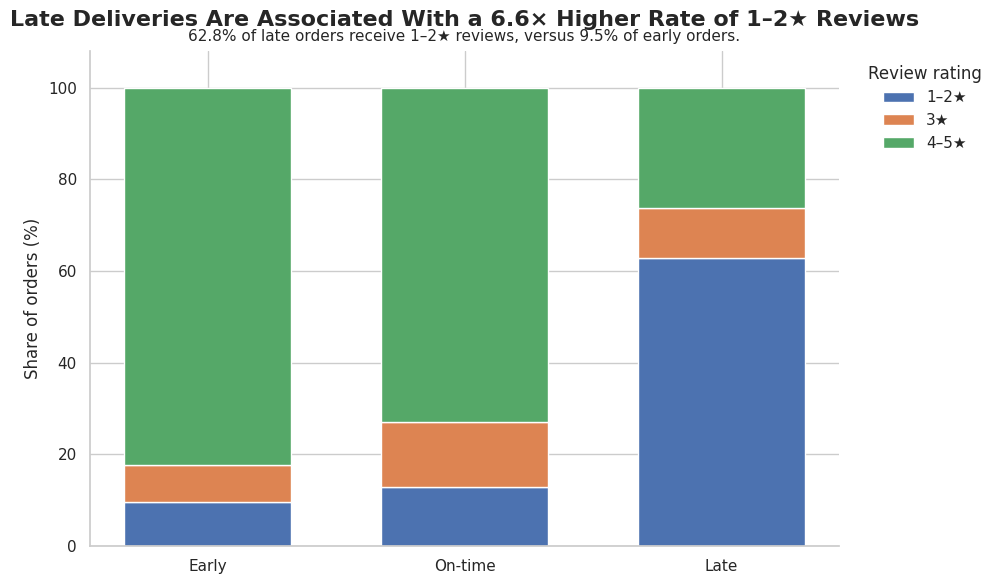

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create rating bands without np.select
plot_data = delivery_review_df.copy()

plot_data["rating_band"] = "3★"
plot_data.loc[plot_data["review_score"] <= 2, "rating_band"] = "1–2★"
plot_data.loc[plot_data["review_score"] >= 4, "rating_band"] = "4–5★"

# Count orders by delivery status and rating band
plot_df = (
    plot_data
    .groupby(["delivery_status", "rating_band"])
    .size()
    .unstack(fill_value=0)
)

# Intended order
status_order = ["Early", "On-time", "Late"]
rating_order = ["1–2★", "3★", "4–5★"]

plot_df = plot_df.reindex(
    index=status_order,
    columns=rating_order,
    fill_value=0
)

# Convert counts to percentages
plot_pct = plot_df.div(plot_df.sum(axis=1), axis=0) * 100

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(plot_pct))

for rating in rating_order:
    values = plot_pct[rating].values

    ax.bar(
        plot_pct.index,
        values,
        bottom=bottom,
        label=rating,
        width=0.65
    )

    bottom += values

# Title
ax.set_title(
    "Late Deliveries Are Associated With a 6.6× Higher Rate of 1–2★ Reviews",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.text(
    0.5,
    1.02,
    "62.8% of late orders receive 1–2★ reviews, versus 9.5% of early orders.",
    transform=ax.transAxes,
    ha="center",
    fontsize=11
)

ax.set_ylabel("Share of orders (%)")
ax.set_xlabel("")
ax.set_ylim(0, 108)

ax.legend(
    title="Review rating",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

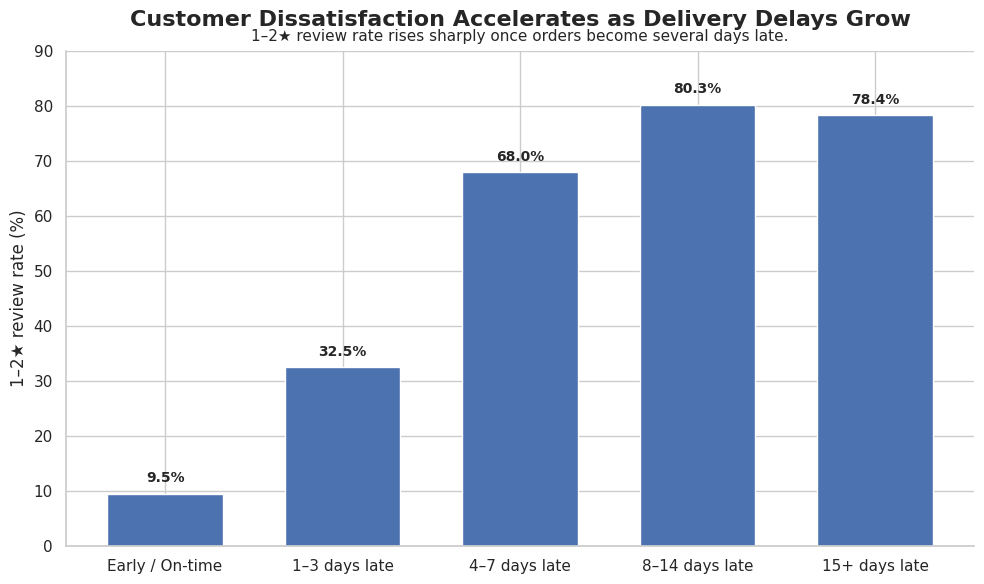

In [ ]:
import matplotlib.pyplot as plt

# Build delay-severity summary
severity_df = (
    delivery_review_df
    .assign(
        delay_bucket=pd.cut(
            delivery_review_df["delivery_delay_days"],
            bins=[-float("inf"), 0, 3, 7, 14, float("inf")],
            labels=["Early / On-time", "1–3 days late", "4–7 days late",
                    "8–14 days late", "15+ days late"]
        ),
        low_review_flag=delivery_review_df["review_score"] <= 2
    )
    .groupby("delay_bucket", observed=False)
    .agg(
        orders=("order_id", "count"),
        low_review_rate=("low_review_flag", "mean")
    )
)

severity_df["low_review_rate"] *= 100

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

x = severity_df.index.astype(str)
y = severity_df["low_review_rate"]

bars = ax.bar(x, y, width=0.65)

# Data labels
for bar, value in zip(bars, y):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Customer Dissatisfaction Accelerates as Delivery Delays Grow",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.text(
    0.5,
    1.02,
    "1–2★ review rate rises sharply once orders become several days late.",
    transform=ax.transAxes,
    ha="center",
    fontsize=11
)

ax.set_ylabel("1–2★ review rate (%)")
ax.set_xlabel("")
ax.set_ylim(0, 90)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

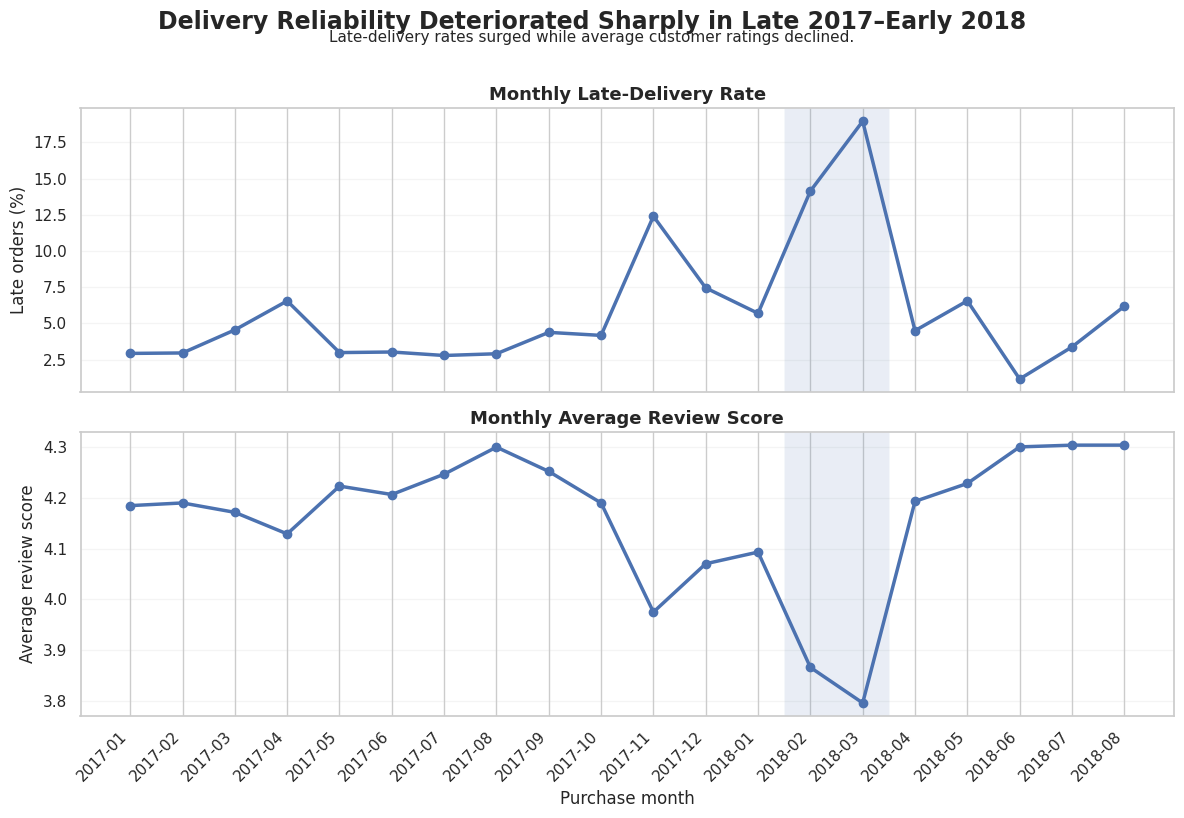

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Copy and standardize month format
timeline = monthly_performance.copy()

timeline["month"] = pd.to_datetime(
    timeline["purchase_month"]
).dt.to_period("M")

timeline = timeline.sort_values("month")

# Keep the meaningful analysis period
timeline = timeline[
    (timeline["month"] >= pd.Period("2017-01", freq="M")) &
    (timeline["month"] <= pd.Period("2018-08", freq="M"))
].copy()

# Numeric x positions
x = np.arange(len(timeline))

# Find crisis months
feb_idx = timeline.index[timeline["month"] == pd.Period("2018-02", freq="M")][0]
mar_idx = timeline.index[timeline["month"] == pd.Period("2018-03", freq="M")][0]

feb_pos = timeline.index.get_loc(feb_idx)
mar_pos = timeline.index.get_loc(mar_idx)

# -----------------------------------
# Create figure
# -----------------------------------

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True
)

# -----------------------------------
# PANEL 1 — Late delivery rate
# -----------------------------------

axes[0].plot(
    x,
    timeline["late_rate"],
    marker="o",
    linewidth=2.5
)

axes[0].set_title(
    "Monthly Late-Delivery Rate",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_ylabel("Late orders (%)")

axes[0].grid(
    axis="y",
    alpha=0.2
)

# Highlight Feb–Mar 2018
axes[0].axvspan(
    feb_pos - 0.5,
    mar_pos + 0.5,
    alpha=0.12
)

# -----------------------------------
# PANEL 2 — Average review score
# -----------------------------------

axes[1].plot(
    x,
    timeline["avg_review_score"],
    marker="o",
    linewidth=2.5
)

axes[1].set_title(
    "Monthly Average Review Score",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_ylabel("Average review score")
axes[1].set_xlabel("Purchase month")

axes[1].grid(
    axis="y",
    alpha=0.2
)

# Highlight Feb–Mar 2018
axes[1].axvspan(
    feb_pos - 0.5,
    mar_pos + 0.5,
    alpha=0.12
)

# -----------------------------------
# X-axis labels
# -----------------------------------

labels = timeline["month"].astype(str)

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    labels,
    rotation=45,
    ha="right"
)

# -----------------------------------
# Overall title
# -----------------------------------

fig.suptitle(
    "Delivery Reliability Deteriorated Sharply in Late 2017–Early 2018",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    0.98,
    "Late-delivery rates surged while average customer ratings declined.",
    ha="center",
    fontsize=11
)

plt.tight_layout()
plt.show()

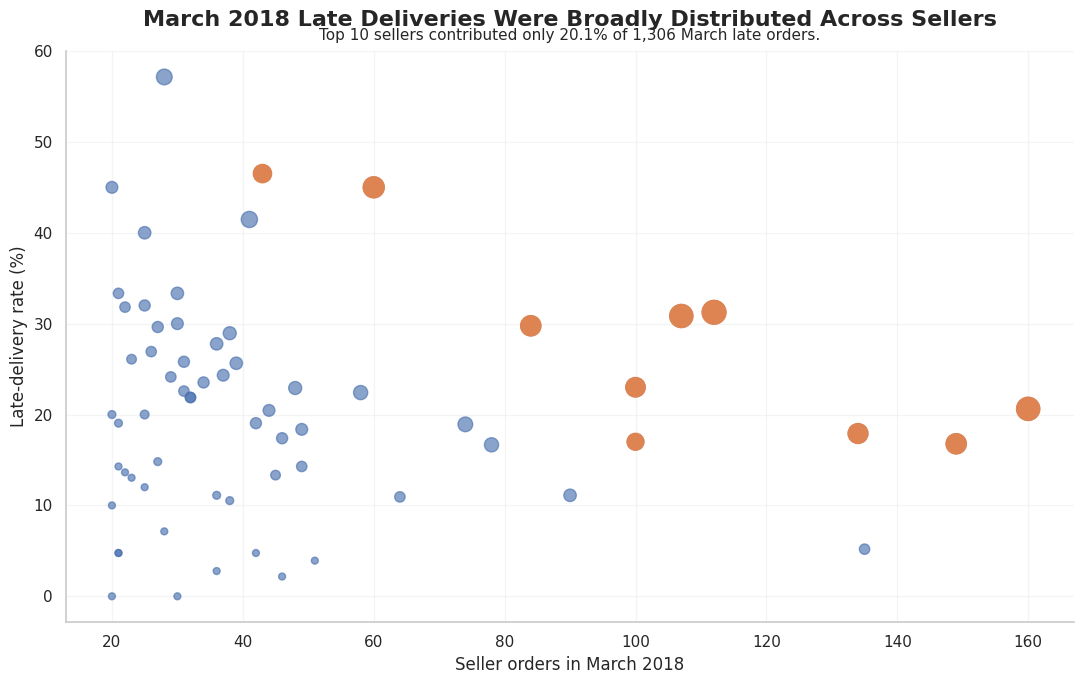

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------
# Prepare March 2018 seller-level data
# ---------------------------------------

march = delivery_category_seller.copy()

march["purchase_month"] = pd.to_datetime(
    march["order_purchase_timestamp"]
).dt.to_period("M")

march = march[
    march["purchase_month"] == pd.Period("2018-03", freq="M")
].copy()

march["is_late"] = march["delivery_status"] == "Late"

seller_march = (
    march
    .groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        late_orders=("is_late", "sum")
    )
    .reset_index()
)

seller_march["late_rate"] = (
    seller_march["late_orders"] /
    seller_march["orders"] * 100
)

# Keep sellers with at least 20 orders
seller_march = seller_march[
    seller_march["orders"] >= 20
].copy()

# ---------------------------------------
# Calculate top-10 concentration
# ---------------------------------------

top10 = (
    seller_march
    .sort_values("late_orders", ascending=False)
    .head(10)
)

top10_late = top10["late_orders"].sum()

total_march_late = march["is_late"].sum()

top10_share = top10_late / total_march_late * 100

# ---------------------------------------
# Plot
# ---------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    seller_march["orders"],
    seller_march["late_rate"],
    s=np.maximum(seller_march["late_orders"] * 8, 25),
    alpha=0.65
)

# Highlight top 10 sellers
ax.scatter(
    top10["orders"],
    top10["late_rate"],
    s=np.maximum(top10["late_orders"] * 8, 40),
    linewidth=1.5
)

ax.set_title(
    "March 2018 Late Deliveries Were Broadly Distributed Across Sellers",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.text(
    0.5,
    1.02,
    f"Top 10 sellers contributed only {top10_share:.1f}% of {total_march_late:,} March late orders.",
    transform=ax.transAxes,
    ha="center",
    fontsize=11
)

ax.set_xlabel("Seller orders in March 2018")
ax.set_ylabel("Late-delivery rate (%)")

ax.grid(
    axis="both",
    alpha=0.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

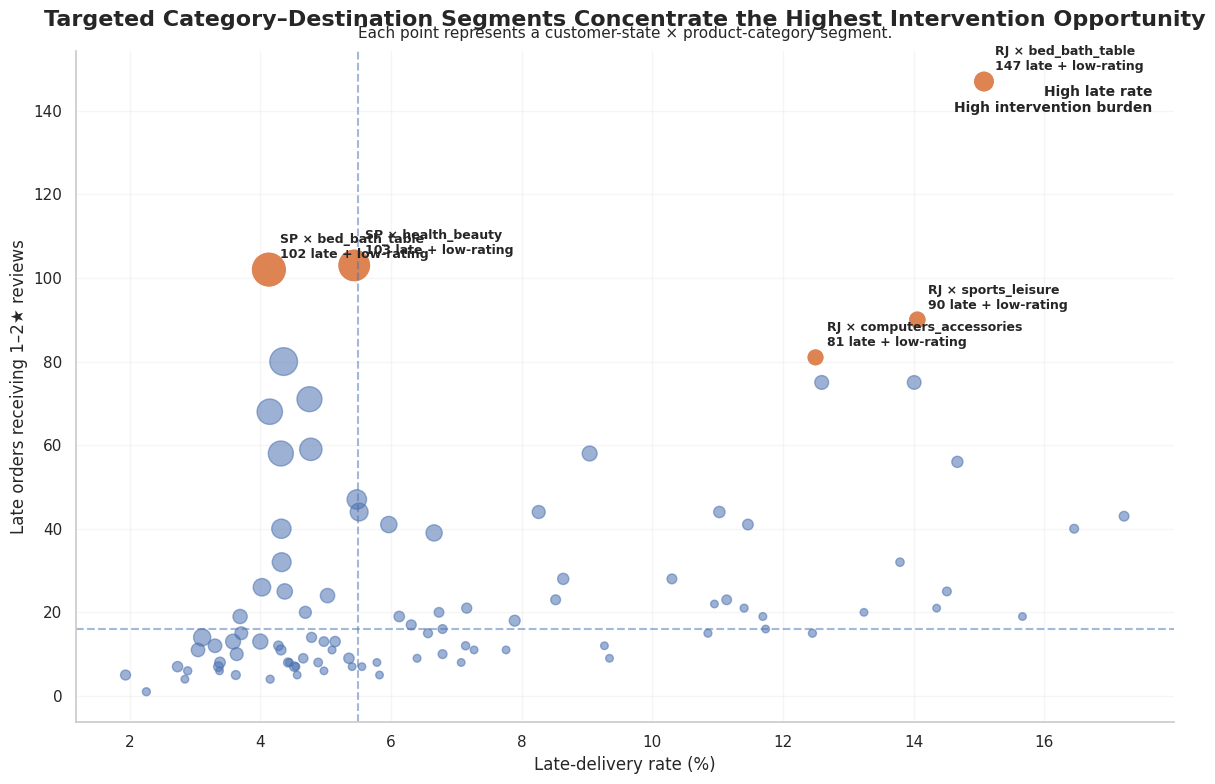

,customer_state,product_category_name_english,total_orders,late_orders,late_rate,late_low_review_orders
0,RJ,bed_bath_table,1333,201,15.078770,147
1,SP,health_beauty,3678,200,5.437738,103
2,SP,bed_bath_table,4260,176,4.131455,102
3,RJ,sports_leisure,882,124,14.058957,90
4,RJ,computers_accessories,824,103,12.500000,81


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------
# Prepare category × state priority data
# ---------------------------------------

priority_plot = delivery_category_geo.copy()

priority_plot["is_late"] = (
    priority_plot["delivery_status"] == "Late"
)

priority_plot["is_low_review"] = (
    priority_plot["review_score"] <= 2
)

priority_plot = (
    priority_plot
    .groupby(
        ["customer_state", "product_category_name_english"],
        dropna=False
    )
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("is_late", "sum"),
        low_review_orders=("is_low_review", "sum")
    )
    .reset_index()
)

# Keep sufficiently large segments
priority_plot = priority_plot[
    priority_plot["total_orders"] >= 200
].copy()

# Late rate
priority_plot["late_rate"] = (
    priority_plot["late_orders"] /
    priority_plot["total_orders"] * 100
)

# Late + low-rating burden
# We estimate how many late orders also have low ratings
late_low = (
    delivery_category_geo[
        delivery_category_geo["delivery_status"] == "Late"
    ]
    .assign(
        is_low_review=lambda x: x["review_score"] <= 2
    )
    .groupby(
        ["customer_state", "product_category_name_english"]
    )
    .agg(
        late_low_review_orders=("is_low_review", "sum"),
        late_orders=("order_id", "nunique")
    )
    .reset_index()
)

priority_plot = priority_plot.merge(
    late_low[
        [
            "customer_state",
            "product_category_name_english",
            "late_low_review_orders"
        ]
    ],
    on=[
        "customer_state",
        "product_category_name_english"
    ],
    how="left"
)

priority_plot["late_low_review_orders"] = (
    priority_plot["late_low_review_orders"].fillna(0)
)

# ---------------------------------------
# Identify top intervention segments
# ---------------------------------------

top_segments = (
    priority_plot
    .sort_values(
        "late_low_review_orders",
        ascending=False
    )
    .head(5)
)

# ---------------------------------------
# Plot
# ---------------------------------------

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    priority_plot["late_rate"],
    priority_plot["late_low_review_orders"],
    s=np.maximum(
        priority_plot["total_orders"] / 8,
        30
    ),
    alpha=0.55
)

# Highlight top 5
ax.scatter(
    top_segments["late_rate"],
    top_segments["late_low_review_orders"],
    s=np.maximum(
        top_segments["total_orders"] / 8,
        80
    ),
    linewidth=1.5
)

# ---------------------------------------
# Labels for top 5
# ---------------------------------------

for _, row in top_segments.iterrows():

    label = (
        f'{row["customer_state"]} × '
        f'{row["product_category_name_english"]}\n'
        f'{int(row["late_low_review_orders"])} late + low-rating'
    )

    ax.annotate(
        label,
        (
            row["late_rate"],
            row["late_low_review_orders"]
        ),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold"
    )

# ---------------------------------------
# Reference lines
# ---------------------------------------

median_late_rate = priority_plot["late_rate"].median()
median_burden = priority_plot["late_low_review_orders"].median()

ax.axvline(
    median_late_rate,
    linestyle="--",
    alpha=0.5
)

ax.axhline(
    median_burden,
    linestyle="--",
    alpha=0.5
)

# Quadrant labels
ax.text(
    0.98,
    0.95,
    "High late rate\nHigh intervention burden",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    fontweight="bold"
)

# ---------------------------------------
# Titles
# ---------------------------------------

ax.set_title(
    "Targeted Category–Destination Segments Concentrate the Highest Intervention Opportunity",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.text(
    0.5,
    1.02,
    "Each point represents a customer-state × product-category segment.",
    transform=ax.transAxes,
    ha="center",
    fontsize=11
)

ax.set_xlabel(
    "Late-delivery rate (%)"
)

ax.set_ylabel(
    "Late orders receiving 1–2★ reviews"
)

ax.grid(
    alpha=0.18
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# ---------------------------------------
# Show top 5 table
# ---------------------------------------

top_segments[
    [
        "customer_state",
        "product_category_name_english",
        "total_orders",
        "late_orders",
        "late_rate",
        "late_low_review_orders"
    ]
].reset_index(drop=True)

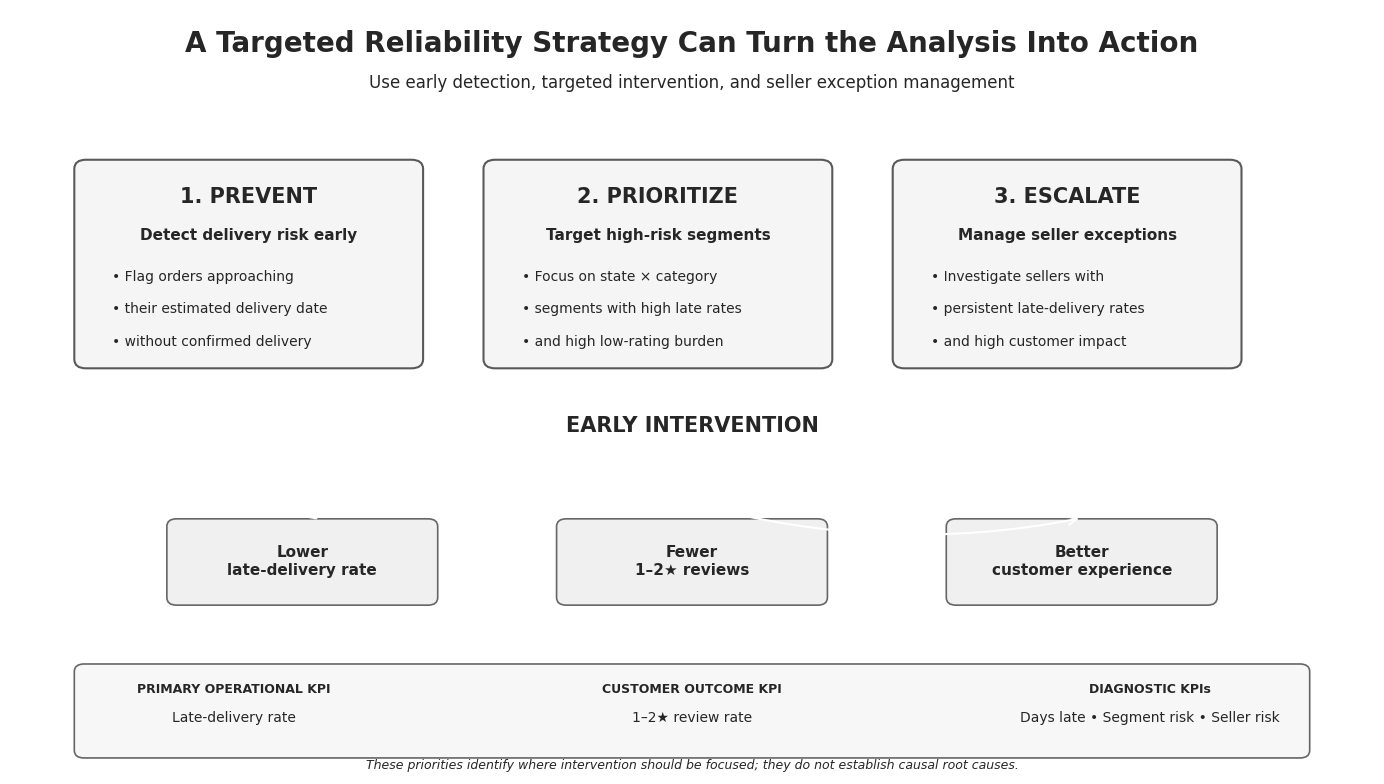

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ---------------------------------------------------------
# Executive recommendation framework
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 8))

ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis("off")

# ---------------------------------------------------------
# Title
# ---------------------------------------------------------

ax.text(
    7, 9.55,
    "A Targeted Reliability Strategy Can Turn the Analysis Into Action",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold"
)

ax.text(
    7, 9.05,
    "Use early detection, targeted intervention, and seller exception management",
    ha="center",
    va="center",
    fontsize=12
)

# ---------------------------------------------------------
# Three action cards
# ---------------------------------------------------------

cards = [
    {
        "x": 0.7,
        "title": "1. PREVENT",
        "subtitle": "Detect delivery risk early",
        "points": [
            "Flag orders approaching",
            "their estimated delivery date",
            "without confirmed delivery"
        ]
    },
    {
        "x": 4.9,
        "title": "2. PRIORITIZE",
        "subtitle": "Target high-risk segments",
        "points": [
            "Focus on state × category",
            "segments with high late rates",
            "and high low-rating burden"
        ]
    },
    {
        "x": 9.1,
        "title": "3. ESCALATE",
        "subtitle": "Manage seller exceptions",
        "points": [
            "Investigate sellers with",
            "persistent late-delivery rates",
            "and high customer impact"
        ]
    }
]

for card in cards:

    box = FancyBboxPatch(
        (card["x"], 5.35),
        3.5,
        2.65,
        boxstyle="round,pad=0.04,rounding_size=0.12",
        linewidth=1.5,
        edgecolor="0.35",
        facecolor="0.96"
    )

    ax.add_patch(box)

    ax.text(
        card["x"] + 1.75,
        7.55,
        card["title"],
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold"
    )

    ax.text(
        card["x"] + 1.75,
        7.05,
        card["subtitle"],
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    for i, point in enumerate(card["points"]):
        ax.text(
            card["x"] + 0.35,
            6.50 - i * 0.42,
            "• " + point,
            ha="left",
            va="center",
            fontsize=10
        )

# ---------------------------------------------------------
# Arrows between cards
# ---------------------------------------------------------

arrow_style = dict(
    arrowstyle="->",
    mutation_scale=20,
    linewidth=2
)

ax.add_patch(
    FancyArrowPatch(
        (4.25, 6.65),
        (4.75, 6.65),
        **arrow_style
    )
)

ax.add_patch(
    FancyArrowPatch(
        (8.45, 6.65),
        (8.95, 6.65),
        **arrow_style
    )
)

# ---------------------------------------------------------
# Early intervention → outcomes
# ---------------------------------------------------------

ax.text(
    7,
    4.55,
    "EARLY INTERVENTION",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

ax.add_patch(
    FancyArrowPatch(
        (7, 4.25),
        (7, 3.55),
        **arrow_style
    )
)

# Outcome boxes
outcomes = [
    (3.0, "Lower\nlate-delivery rate"),
    (7.0, "Fewer\n1–2★ reviews"),
    (11.0, "Better\ncustomer experience")
]

for x, text in outcomes:

    box = FancyBboxPatch(
        (x - 1.35, 2.25),
        2.7,
        1.05,
        boxstyle="round,pad=0.04,rounding_size=0.1",
        linewidth=1.2,
        edgecolor="0.4",
        facecolor="0.94"
    )

    ax.add_patch(box)

    ax.text(
        x,
        2.78,
        text,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Connect intervention to outcomes
for x in [3.0, 7.0, 11.0]:

    ax.add_patch(
        FancyArrowPatch(
            (7, 3.55),
            (x, 3.35),
            connectionstyle="arc3,rad=0.12" if x != 7 else "arc3",
            arrowstyle="->",
            mutation_scale=15,
            linewidth=1.5
        )
    )

# ---------------------------------------------------------
# KPI strip
# ---------------------------------------------------------

kpi_y = 0.75

ax.add_patch(
    FancyBboxPatch(
        (0.7, 0.25),
        12.6,
        1.15,
        boxstyle="round,pad=0.04,rounding_size=0.1",
        linewidth=1.2,
        edgecolor="0.4",
        facecolor="0.97"
    )
)

kpis = [
    (2.3, "PRIMARY OPERATIONAL KPI", "Late-delivery rate"),
    (7.0, "CUSTOMER OUTCOME KPI", "1–2★ review rate"),
    (11.7, "DIAGNOSTIC KPIs", "Days late • Segment risk • Seller risk")
]

for x, heading, value in kpis:

    ax.text(
        x,
        kpi_y + 0.35,
        heading,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

    ax.text(
        x,
        kpi_y - 0.02,
        value,
        ha="center",
        va="center",
        fontsize=10
    )

# ---------------------------------------------------------
# Footer caveat
# ---------------------------------------------------------

ax.text(
    7,
    0.03,
    "These priorities identify where intervention should be focused; they do not establish causal root causes.",
    ha="center",
    va="bottom",
    fontsize=9,
    style="italic"
)

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# FINAL CORRECT MARKETPLACE RELIABILITY SHOCK
# Using validated delivered-order level data
# =========================================================

crisis_data = delivery_review_df.copy()

# Purchase month
crisis_data["purchase_month"] = pd.to_datetime(
    crisis_data["order_purchase_timestamp"]
).dt.to_period("M")

# Define periods
pre_crisis = crisis_data[
    crisis_data["purchase_month"].isin([
        pd.Period("2017-08", freq="M"),
        pd.Period("2017-09", freq="M"),
        pd.Period("2017-10", freq="M")
    ])
].copy()

crisis = crisis_data[
    crisis_data["purchase_month"].isin([
        pd.Period("2018-02", freq="M"),
        pd.Period("2018-03", freq="M")
    ])
].copy()

# ---------------------------------------------------------
# Calculate metrics directly from order-level observations
# ---------------------------------------------------------

pre_orders = pre_crisis["order_id"].nunique()
crisis_orders = crisis["order_id"].nunique()

pre_late_orders = (
    pre_crisis["delivery_status"] == "Late"
).sum()

crisis_late_orders = (
    crisis["delivery_status"] == "Late"
).sum()

pre_late_rate = pre_late_orders / pre_orders * 100
crisis_late_rate = crisis_late_orders / crisis_orders * 100

pre_review = pre_crisis["review_score"].mean()
crisis_review = crisis["review_score"].mean()

# Changes
late_rate_change_pp = crisis_late_rate - pre_late_rate
late_rate_relative_change = (
    crisis_late_rate / pre_late_rate - 1
) * 100

late_order_relative_change = (
    crisis_late_orders / pre_late_orders - 1
) * 100

review_change = crisis_review - pre_review

# ---------------------------------------------------------
# Final table
# ---------------------------------------------------------

final_crisis_summary = pd.DataFrame({
    "Metric": [
        "Orders",
        "Late orders",
        "Late-delivery rate",
        "Average review score"
    ],
    "Pre-crisis (Aug–Oct 2017)": [
        pre_orders,
        pre_late_orders,
        pre_late_rate,
        pre_review
    ],
    "Crisis (Feb–Mar 2018)": [
        crisis_orders,
        crisis_late_orders,
        crisis_late_rate,
        crisis_review
    ]
})

print("=" * 70)
print("FINAL MARKETPLACE RELIABILITY SHOCK")
print("=" * 70)

display(final_crisis_summary.round(3))

print("\nChanges:")
print(f"Late rate: +{late_rate_change_pp:.2f} percentage points")
print(f"Late rate relative increase: +{late_rate_relative_change:.2f}%")
print(f"Late orders relative increase: +{late_order_relative_change:.2f}%")
print(f"Average review change: {review_change:.3f} stars")

FINAL MARKETPLACE RELIABILITY SHOCK


,Metric,Pre-crisis (Aug–Oct 2017),Crisis (Feb–Mar 2018)
0,Orders,12821.000,13559.000
1,Late orders,491.000,2255.000
2,Late-delivery rate,3.830,16.631
3,Average review score,4.246,3.830



Changes:
Late rate: +12.80 percentage points
Late rate relative increase: +334.27%
Late orders relative increase: +359.27%
Average review change: -0.416 stars
